In [31]:
import time
import pandas as pd

In [18]:
import gzip
import shutil
import torch
from torch.utils.data import DataLoader
from datasets import load_dataset  # From Hugging Face
import re
import string
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Step 1: load imdb dataset
dataset = load_dataset('imdb')
train_data = dataset['train']
test_data = dataset['test']

Using the latest cached version of the dataset since imdb couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'plain_text' at /home/alireza/.cache/huggingface/datasets/imdb/plain_text/0.0.0/e6281661ce1c48d982bc483cf8a173c1bbeb5d31 (last modified on Thu Feb  5 20:36:42 2026).


In [61]:
# Print samples
print("Sample positive review:", train_data[2]['text'], "Label:", train_data[2]['label'])  # 1 = positive, 0 = negative
print("Sample negative review:", train_data[1]['text'], "Label:", train_data[12500]['label'])

Sample positive review: If only to avoid making this type of film in the future. This film is interesting as an experiment but tells no cogent story.<br /><br />One might feel virtuous for sitting thru it because it touches on so many IMPORTANT issues but it does so without any discernable motive. The viewer comes away with no new perspectives (unless one comes up with one while one's mind wanders, as it will invariably do during this pointless film).<br /><br />One might better spend one's time staring out a window at a tree growing.<br /><br /> Label: 0
Sample negative review: "I Am Curious: Yellow" is a risible and pretentious steaming pile. It doesn't matter what one's political views are because this film can hardly be taken seriously on any level. As for the claim that frontal male nudity is an automatic NC-17, that isn't true. I've seen R-rated films with male nudity. Granted, they only offer some fleeting views, but where are the R-rated films with gaping vulvas and flapping la

In [5]:
train_data.shape

(25000, 2)

In [6]:
test_data.shape

(25000, 2)

In [26]:
with gzip.open('data/movie_data.csv.gz', 'rb') as f_in:
    with open('data/movie_data.csv', 'wb') as f_out:
        shutil.copyfileobj(f_in, f_out)

In [ ]:
import shutil, gzip
shutil.copyfileobj(gzip.open('data/movie_data.csv.gz', 'rb'), open('data/movie_data.csv', 'wb'))

In [33]:
df = pd.read_csv('data/movie_data.csv')

In [34]:
df.shape

(50000, 2)

In [40]:
# Step 2: Explore
labels = [example['label'] for example in train_data]
print("Label distribution: ", np.bincount(labels))
print("Label Category: ", np.unique(labels))

Label distribution:  [12500 12500]
Label Category:  [0 1]


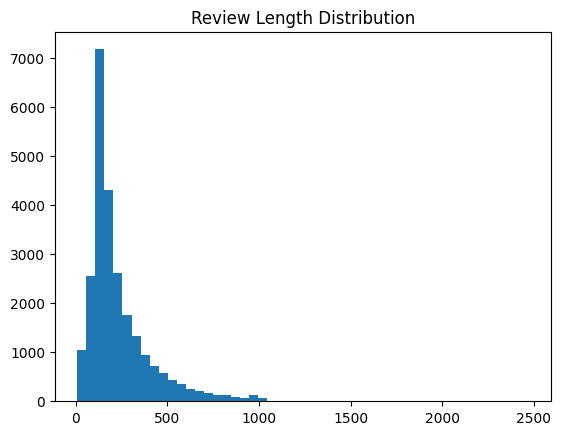

Avg review length: 233.7872


In [51]:
review_lengths = [len(example['text'].split()) for example in train_data]
plt.hist(review_lengths, bins=50)
plt.title("Review Length Distribution")
plt.show()
print("Avg review length:", np.mean(review_lengths))

In [52]:
# Step 3: Preprocess function
def preprocess_text(text):
    text = text.lower()  # Lowercase
    text = re.sub(r'<br />', ' ', text)  # Remove HTML
    text = text.translate(str.maketrans('', '', string.punctuation))  # Remove punctuation
    text = re.sub(r'\d+', '', text)  # Remove numbers (optional)
    return text.split()  # Tokenize into list of words

In [69]:
# Apply to a sample
print("Preprocessed sample:", preprocess_text(train_data[0]['text']))
print(train_data[0]['text'])

Preprocessed sample: ['i', 'rented', 'i', 'am', 'curiousyellow', 'from', 'my', 'video', 'store', 'because', 'of', 'all', 'the', 'controversy', 'that', 'surrounded', 'it', 'when', 'it', 'was', 'first', 'released', 'in', 'i', 'also', 'heard', 'that', 'at', 'first', 'it', 'was', 'seized', 'by', 'us', 'customs', 'if', 'it', 'ever', 'tried', 'to', 'enter', 'this', 'country', 'therefore', 'being', 'a', 'fan', 'of', 'films', 'considered', 'controversial', 'i', 'really', 'had', 'to', 'see', 'this', 'for', 'myself', 'the', 'plot', 'is', 'centered', 'around', 'a', 'young', 'swedish', 'drama', 'student', 'named', 'lena', 'who', 'wants', 'to', 'learn', 'everything', 'she', 'can', 'about', 'life', 'in', 'particular', 'she', 'wants', 'to', 'focus', 'her', 'attentions', 'to', 'making', 'some', 'sort', 'of', 'documentary', 'on', 'what', 'the', 'average', 'swede', 'thought', 'about', 'certain', 'political', 'issues', 'such', 'as', 'the', 'vietnam', 'war', 'and', 'race', 'issues', 'in', 'the', 'united',

In [59]:
df

,review,sentiment
0,"In 1974, the teenager Martha Moxley (Maggie Gr...",1
1,OK... so... I really like Kris Kristofferson a...,0
2,"***SPOILER*** Do not read this, if you think a...",0
3,hi for all the people who have seen this wonde...,1
4,"I recently bought the DVD, forgetting just how...",0
...,...,...
49995,"OK, lets start with the best. the building. al...",0
49996,The British 'heritage film' industry is out of...,0
49997,I don't even know where to begin on this one. ...,0
49998,Richard Tyler is a little boy who is scared of...,0


In [109]:

print(train_data[12502])
print(preprocess_text(train_data[12502]['text']))

{'text': "Lars Von Trier is never backward in trying out new techniques. Some of them are very original while others are best forgotten.<br /><br />He depicts postwar Germany as a nightmarish train journey. With so many cities lying in ruins, Leo Kessler a young American of German descent feels obliged to help in their restoration. It is not a simple task as he quickly finds out.<br /><br />His uncle finds him a job as a night conductor on the Zentropa Railway Line. His job is to attend to the needs of the passengers. When the shoes are polished a chalk mark is made on the soles. A terrible argument ensues when a passenger's shoes are not chalked despite the fact they have been polished. There are many allusions to the German fanaticism of adherence to such stupid details.<br /><br />The railway journey is like an allegory representing man's procession through life with all its trials and tribulations. In one sequence Leo dashes through the back carriages to discover them filled with h

In [86]:
from collections import Counter
word_counts = Counter()
l = [['alireza', 'ali', 'text'], ['ali', 'la', 'lalaa', 'alala', 'ka'], ['ara', 'alsaag']]
for voc in l:
    tokens = voc
    word_counts.update(tokens)

In [97]:
most_common = word_counts.most_common()

In [98]:
for i in word_counts.most_common():
    print(i)

('ali', 2)
('alireza', 1)
('text', 1)
('la', 1)
('lalaa', 1)
('alala', 1)
('ka', 1)
('ara', 1)
('alsaag', 1)


In [101]:
vocab = {'<pad>': 0, '<unk>': 1}
# optionally: '<bos>': 2, '<eos>': 3   (we won't use them here for simplicity)

offset = len(vocab)
for word, _ in most_common:
    vocab[word] = offset
    offset += 1
    print(offset)

3
4
5
6
7
8
9
10
11


In [100]:
vocab

{'<pad>': 0,
 '<unk>': 1,
 'ali': 2,
 'alireza': 3,
 'text': 4,
 'la': 5,
 'lalaa': 6,
 'alala': 7,
 'ka': 8,
 'ara': 9,
 'alsaag': 10}

In [103]:
print(f"Vocabulary size: {len(vocab)} (including specials)")
print("Top 10 words:", most_common[:3])

Vocabulary size: 11 (including specials)
Top 10 words: [('ali', 2), ('alireza', 1), ('text', 1)]


Vocabulary size: 25000 (including specials)
Top 10 words: [('the', 334765), ('and', 162270), ('a', 161983), ('of', 145382), ('to', 135116), ('is', 107042), ('in', 93130), ('it', 78104), ('i', 75750), ('this', 75439)]


In [131]:
len(vocab)

24998

In [125]:
min(5, 6)

5

In [127]:
min(500, len(word_counts.most_common()))

109227

In [128]:
num_of_special_char

2

In [146]:
text = "Heelo :) :( :) :) :) :("

In [147]:
emoticon_pattern = r"""
        (?:
            [<>]?[=:;8xX][-o^*']?[()DdpP3oO/\\/|]   # :)  :(  :D  :P  ;-)  8-) etc.
            | [()DdpP3][-o^*']?[=:;8xX][<>]?          # reverse faces
            | <3                                      # heart
            | [Uu][Uu]                                # ^_^  u.u
            | [Xx][Dd]                                # xD
        )
    """
emoticons = re.findall(emoticon_pattern, text, re.IGNORECASE | re.VERBOSE)

In [148]:
emoticons

[':)', ':(', ':)', ':)', ':)', ':(']

In [149]:
placeholders = {}
for i, emo in enumerate(emoticons):
    placeholder = f' __EMO_{i}__ '
    placeholders[placeholder] = emo.lower()  # store lowercase version
    text = text.replace(emo, placeholder)

In [150]:
text

'Heelo  __EMO_0__   __EMO_1__   __EMO_0__   __EMO_0__   __EMO_0__   __EMO_1__ '

In [151]:
import re
import string

def better_tokenizer(text):
    """
    Improved tokenizer for sentiment analysis / text classification:
    - Removes HTML tags completely
    - Preserves common emoticons as tokens
    - Keeps contractions, @mentions, #hashtags, ! and ?
    - Removes most other punctuation & normalizes spaces
    - Lowercases everything
    """
    if not isinstance(text, str) or not text.strip():
        return []

    # 1. Remove all HTML tags
    text = re.sub(r'<[^>]*>', '', text)

    # 2. Extract common emoticons (very simple & popular set)
    emoticon_pattern = r"""
        (?:
            [<>]?[=:;8xX][-o^*']?[()DdpP3oO/\\/|]   # :)  :(  :D  :P  ;-)  8-) etc.
            | [()DdpP3][-o^*']?[=:;8xX][<>]?          # reverse faces
            | <3                                      # heart
            | [Uu][Uu]                                # ^_^  u.u
            | [Xx][Dd]                                # xD
        )
    """
    emoticons = re.findall(emoticon_pattern, text, re.IGNORECASE | re.VERBOSE)

    # 3. Lowercase once (before we do heavy replacements)
    text = text.lower()

    # 4. Protect emoticons with unique placeholders
    placeholders = {}
    for i, emo in enumerate(emoticons):
        placeholder = f' __EMO_{i}__ '
        placeholders[placeholder] = emo.lower()  # store lowercase version
        text = text.replace(emo, placeholder)

    # 5. Replace <br/> variants that might have survived
    text = re.sub(r'<br\s*/?>|\n|\r', ' ', text)

    # 6. Remove URLs but keep domain-ish part (optional aggressive version)
    # text = re.sub(r'https?://\S+|www\.\S+', ' __URL__ ', text)

    # 7. Keep useful tokens, remove most punctuation except ! ? ' @ # 
    keep_chars = "!?'@#"
    to_remove = ''.join(c for c in string.punctuation if c not in keep_chars)
    text = text.translate(str.maketrans('', '', to_remove))

    # 8. Normalize multiple spaces / cleanup
    text = re.sub(r'\s+', ' ', text).strip()

    # 9. Put protected emoticons back
    for ph, emo in placeholders.items():
        text = text.replace(ph.strip(), emo)  # remove extra spaces around placeholder

    # 10. Final split
    tokens = text.split()

    return tokens

In [167]:
def tokenizer(text):
    text = re.sub(r'<[^>]*>', '', text)
    emoticons = re.findall(r'(?::|;|=)(?:-)?(?:\)|\(|D|P)', text.lower())
    text = re.sub(r'[\W]+', ' ', text.lower()) + ' '.join(emoticons).replace('-', '')
    tokenized = text.split()
    return tokenized

In [168]:
idx = 0

In [173]:
idx += 1
print(preprocess_text(train_data[idx]['text']), len(preprocess_text(train_data[idx]['text'])))
print(better_tokenizer(train_data[idx]['text']), len(better_tokenizer(train_data[idx]['text'])))
print(tokenizer(train_data[idx]['text']), len(tokenizer(train_data[idx]['text'])))

['i', 'would', 'put', 'this', 'at', 'the', 'top', 'of', 'my', 'list', 'of', 'films', 'in', 'the', 'category', 'of', 'unwatchable', 'trash', 'there', 'are', 'films', 'that', 'are', 'bad', 'but', 'the', 'worst', 'kind', 'are', 'the', 'ones', 'that', 'are', 'unwatchable', 'but', 'you', 'are', 'suppose', 'to', 'like', 'them', 'because', 'they', 'are', 'supposed', 'to', 'be', 'good', 'for', 'you', 'the', 'sex', 'sequences', 'so', 'shocking', 'in', 'its', 'day', 'couldnt', 'even', 'arouse', 'a', 'rabbit', 'the', 'so', 'called', 'controversial', 'politics', 'is', 'strictly', 'high', 'school', 'sophomore', 'amateur', 'night', 'marxism', 'the', 'film', 'is', 'selfconsciously', 'arty', 'in', 'the', 'worst', 'sense', 'of', 'the', 'term', 'the', 'photography', 'is', 'in', 'a', 'harsh', 'grainy', 'black', 'and', 'white', 'some', 'scenes', 'are', 'out', 'of', 'focus', 'or', 'taken', 'from', 'the', 'wrong', 'angle', 'even', 'the', 'sound', 'is', 'bad', 'and', 'some', 'people', 'call', 'this', 'art'] 

In [174]:
from collections import Counter
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np

# ────────────────────────────────────────────────
#   Build vocabulary from training data only
# ────────────────────────────────────────────────

VOCAB_SIZE = 25000      # adjust between 10k–40k depending on memory/time
MIN_FREQ = 2            # words that appear < MIN_FREQ times are <unk>

# Count all words in preprocessed training reviews
word_counts = Counter()

for example in train_data:
    tokens = preprocess_text(example['text'])
    word_counts.update(tokens)

# Create vocab dictionary
vocab = {'<pad>': 0, '<unk>': 1}
# optionally: '<bos>': 2, '<eos>': 3   (we won't use them here for simplicity)


num_of_special_char = len(vocab)
# Most common words
most_common = word_counts.most_common(min(VOCAB_SIZE, len(word_counts.most_common())) - num_of_special_char)  # reserve space for specials




offset = len(vocab)
for word, _ in most_common:
    vocab[word] = offset
    offset += 1

print(f"Vocabulary size: {len(vocab)} (including specials)")
print("Top 10 words:", most_common[:10])

Vocabulary size: 25000 (including specials)
Top 10 words: [('the', 334765), ('and', 162270), ('a', 161983), ('of', 145382), ('to', 135116), ('is', 107042), ('in', 93130), ('it', 78104), ('i', 75750), ('this', 75439)]


In [198]:
def text_to_indices(text, vocab, max_len=200):
    tokens = preprocess_text(text)
    indices = [vocab.get(token, vocab['<unk>']) for token in tokens]
    # Truncate if too long
    if len(indices) > max_len:
        indices = indices[:max_len]
    return indices

In [201]:
text_to_indices(train_data[0]['text'], vocab, max_len=10)

[10, 1541, 10, 237, 1, 35, 55, 390, 1126, 83]

In [202]:
text_to_indices(train_data[0]['text'], vocab, max_len=10)

[10, 1541, 10, 237, 1, 35, 55, 390, 1126, 83]

In [203]:
class IMDbDataset(Dataset):
    def __init__(self, hf_dataset, vocab, max_len=200):
        self.data = hf_dataset
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        text = self.data[idx]['text']
        label = self.data[idx]['label']   # 0=neg, 1=pos
        indices = text_to_indices(text, self.vocab, self.max_len)
        return {
            'indices': torch.tensor(indices, dtype=torch.long),
            'length': len(indices),           # useful for packing / masking
            'label': torch.tensor(label, dtype=torch.float32)
        }

In [204]:
def collate_fn(batch):
    indices = [item['indices'] for item in batch]
    lengths = [item['length'] for item in batch]
    labels = [item['label'] for item in batch]

    # Pad sequences
    indices_padded = torch.nn.utils.rnn.pad_sequence(
        indices, batch_first=True, padding_value=vocab['<pad>']
    )

    return {
        'indices': indices_padded,
        'lengths': torch.tensor(lengths, dtype=torch.long),
        'labels': torch.tensor(labels, dtype=torch.float32)
    }

In [205]:
MAX_LEN = 200          # ← very important! Choose wisely (see your length histogram)
BATCH_SIZE = 64        # adjust according to GPU memory

train_dataset = IMDbDataset(train_data, vocab, max_len=MAX_LEN)
test_dataset  = IMDbDataset(test_data,  vocab, max_len=MAX_LEN)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=2         # increase if you have good CPU
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE*2,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=2
)

# Quick test
batch = next(iter(train_loader))
print("Batch shapes:")
print("  indices:", batch['indices'].shape)     # [batch, max_len]
print("  lengths:", batch['lengths'].shape)
print("  labels: ", batch['labels'].shape)
print("Example padded sequence:", batch['indices'][0][:15], "...")

Batch shapes:
  indices: torch.Size([64, 200])
  lengths: torch.Size([64])
  labels:  torch.Size([64])
Example padded sequence: tensor([  44,   22,  178,    6,  103,    4,   17,    3,  233,   49,   42,  145,
           9,   91, 9731]) ...


In [206]:
sample_idx = 0
sample_text = train_data[sample_idx]['text'][:300] + "..."
sample_indices = text_to_indices(train_data[sample_idx]['text'], vocab, MAX_LEN)
print("Original text snippet:", sample_text)
print("→ indices (first 20):", sample_indices[:20])

Original text snippet: I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really h...
→ indices (first 20): [10, 1541, 10, 237, 1, 35, 55, 390, 1126, 83, 5, 30, 2, 6942, 12, 3274, 9, 51, 9, 13]


# Build Model

In [208]:
import torch
import torch.nn as nn
import torch.optim as optim

class BasicRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim=1, num_layers=1, dropout=0.3):
        super().__init__()
        
        self.embedding = nn.Embedding(
            vocab_size, 
            embed_dim, 
            padding_idx=0  # important: <pad> token gets zero vector
        )
        
        self.rnn = nn.RNN(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            nonlinearity='tanh',        # or 'relu'
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, indices, lengths=None):
        # indices shape: [batch_size, seq_len]
        
        embedded = self.embedding(indices)          # → [batch, seq_len, embed_dim]
        embedded = self.dropout(embedded)
        
        # RNN expects: batch_first=True → [batch, seq_len, embed_dim]
        output, hidden = self.rnn(embedded)
        
        # hidden shape: [num_layers, batch, hidden_dim]
        # We take the LAST layer's final hidden state
        final_hidden = hidden[-1]                    # [batch, hidden_dim]
        
        final_hidden = self.dropout(final_hidden)
        logits = self.fc(final_hidden)               # [batch, 1]
        return logits.squeeze(1)                     # [batch]

In [221]:
# Hyperparameters – feel free to experiment later
EMBED_DIM   = 100
HIDDEN_DIM  = 256
NUM_LAYERS  = 1          # start with 1 (stacking many vanilla RNNs usually hurts)
DROPOUT     = 0.3
LEARNING_RATE = 0.001
N_EPOCHS    = 100          # we'll do few epochs first → RNN trains slowly

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

model_rnn = BasicRNN(
    vocab_size=len(vocab),
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    output_dim=1,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
).to(device)

criterion = nn.BCEWithLogitsLoss()   # combines sigmoid + binary cross entropy
optimizer = optim.Adam(model_rnn.parameters(), lr=LEARNING_RATE)
# Optional: learning rate scheduler
# scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

Using device: cuda


In [222]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for batch in loader:
        indices = batch['indices'].to(device)
        labels  = batch['labels'].to(device)
        lengths = batch['lengths']           # we don't use packed yet
        
        optimizer.zero_grad()
        logits = model(indices, lengths)
        loss = criterion(logits, labels)
        
        loss.backward()
        # Optional: torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += loss.item()
        preds = (torch.sigmoid(logits) > 0.5).float()
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    
    return total_loss / len(loader), correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for batch in loader:
            indices = batch['indices'].to(device)
            labels  = batch['labels'].to(device)
            lengths = batch['lengths']
            
            logits = model(indices, lengths)
            loss = criterion(logits, labels)
            
            total_loss += loss.item()
            preds = (torch.sigmoid(logits) > 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    
    return total_loss / len(loader), correct / total

In [223]:
print("Starting RNN training...\n")

for epoch in range(1, N_EPOCHS + 1):
    train_loss, train_acc = train_epoch(model_rnn, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model_rnn, test_loader, criterion, device)
    
    print(f"Epoch {epoch}/{N_EPOCHS}")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Valid Loss: {val_loss:.4f} | Valid Acc: {val_acc:.4f}")
    print("-" * 60)
    
    # scheduler.step(val_loss)  # if using scheduler

Starting RNN training...

Epoch 1/100
  Train Loss: 0.6983 | Train Acc: 0.5023
  Valid Loss: 0.6971 | Valid Acc: 0.5026
------------------------------------------------------------
Epoch 2/100
  Train Loss: 0.6973 | Train Acc: 0.5074
  Valid Loss: 0.6951 | Valid Acc: 0.5111
------------------------------------------------------------
Epoch 3/100
  Train Loss: 0.6997 | Train Acc: 0.5040
  Valid Loss: 0.7083 | Valid Acc: 0.4982
------------------------------------------------------------
Epoch 4/100
  Train Loss: 0.6988 | Train Acc: 0.4981
  Valid Loss: 0.6958 | Valid Acc: 0.4946
------------------------------------------------------------
Epoch 5/100
  Train Loss: 0.6985 | Train Acc: 0.5040
  Valid Loss: 0.7067 | Valid Acc: 0.4956
------------------------------------------------------------
Epoch 6/100
  Train Loss: 0.6975 | Train Acc: 0.5010
  Valid Loss: 0.6962 | Valid Acc: 0.5047
------------------------------------------------------------
Epoch 7/100
  Train Loss: 0.6963 | Train Acc

KeyboardInterrupt: 

In [224]:
def predict_sample(model, dataset, idx=0):
    model.eval()
    item = dataset[idx]
    indices = item['indices'].unsqueeze(0).to(device)  # add batch dim
    with torch.no_grad():
        logit = model(indices)
        prob = torch.sigmoid(logit).item()
    true_label = "positive" if item['label'] == 1 else "negative"
    pred_label = "positive" if prob > 0.5 else "negative"
    print(f"True: {true_label} | Pred: {pred_label} ({prob:.4f})")
    print("Text snippet:", dataset.data[idx]['text'][:250], "...\n")

predict_sample(model_rnn, test_dataset, idx=42)   # try a few indices

True: negative | Pred: positive (0.8928)
Text snippet: I have no idea how anyone can give this movie high marks. I didn't rent it thinking it was the next great horror flick, the next great horror spoof, or the next great low-budget horror spoof. Obviously, this isn't meant to scare, but one fatal flaw w ...



# LSTM

In [248]:
class BasicLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim=1, 
                 num_layers=1, dropout=0.3, bidirectional=False):
        super().__init__()
        
        self.embedding = nn.Embedding(
            vocab_size, 
            embed_dim, 
            padding_idx=0
        )
        
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=bidirectional
        )
        
        # ──── IMPORTANT CHANGE ────
        # Calculate the size that will come out of the last hidden state
        self.lstm_output_dim = hidden_dim * 2 if bidirectional else hidden_dim
        
        self.fc = nn.Linear(self.lstm_output_dim, output_dim)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, indices, lengths=None):
        embedded = self.embedding(indices)
        embedded = self.dropout(embedded)
        
        output, (hidden, cell) = self.lstm(embedded)
        
        # hidden shape: [num_layers * num_directions, batch, hidden_dim]
        
        if self.lstm.bidirectional:
            # Concatenate last forward ([-2]) and last backward ([-1])
            final_hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
            # shape becomes [batch, hidden_dim * 2]
        else:
            # Just take the last layer
            final_hidden = hidden[-1]
            # shape [batch, hidden_dim]
        
        final_hidden = self.dropout(final_hidden)
        logits = self.fc(final_hidden)
        return logits.squeeze(1)

In [249]:
EMBED_DIM    = 128          # increased a bit
HIDDEN_DIM   = 256
NUM_LAYERS   = 1            # start with 1
DROPOUT      = 0.4          # slightly higher
BIDIRECTIONAL = True       # try True later (stronger but 2× slower)
LEARNING_RATE = 0.0008      # lower than before
N_EPOCHS     = 8            # LSTMs usually converge faster

# Re-create model
model_lstm = BasicLSTM(
    vocab_size=len(vocab),
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    output_dim=1,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    bidirectional=BIDIRECTIONAL
).to(device)

optimizer = optim.Adam(model_lstm.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)  # small L2
criterion = nn.BCEWithLogitsLoss()

In [250]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for batch in loader:
        indices = batch['indices'].to(device)
        labels  = batch['labels'].to(device)
        lengths = batch['lengths']           # we don't use packed yet
        
        optimizer.zero_grad()
        logits = model(indices, lengths)
        loss = criterion(logits, labels)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        # Optional: torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += loss.item()
        preds = (torch.sigmoid(logits) > 0.5).float()
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    
    return total_loss / len(loader), correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for batch in loader:
            indices = batch['indices'].to(device)
            labels  = batch['labels'].to(device)
            lengths = batch['lengths']
            
            logits = model(indices, lengths)
            loss = criterion(logits, labels)
            
            total_loss += loss.item()
            preds = (torch.sigmoid(logits) > 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    
    return total_loss / len(loader), correct / total

In [251]:
print("Starting RNN training...\n")

for epoch in range(1, N_EPOCHS + 1):
    train_loss, train_acc = train_epoch(model_lstm, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model_lstm, test_loader, criterion, device)
    
    print(f"Epoch {epoch}/{N_EPOCHS}")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Valid Loss: {val_loss:.4f} | Valid Acc: {val_acc:.4f}")
    print("-" * 60)
    
    # scheduler.step(val_loss)  # if using scheduler

Starting RNN training...

Epoch 1/8
  Train Loss: 0.6698 | Train Acc: 0.5885
  Valid Loss: 0.6117 | Valid Acc: 0.6821
------------------------------------------------------------
Epoch 2/8
  Train Loss: 0.6121 | Train Acc: 0.6715
  Valid Loss: 0.5750 | Valid Acc: 0.6928
------------------------------------------------------------
Epoch 3/8
  Train Loss: 0.5370 | Train Acc: 0.7395
  Valid Loss: 0.5635 | Valid Acc: 0.7582
------------------------------------------------------------
Epoch 4/8
  Train Loss: 0.4493 | Train Acc: 0.7966
  Valid Loss: 0.4722 | Valid Acc: 0.8168
------------------------------------------------------------
Epoch 5/8
  Train Loss: 0.3835 | Train Acc: 0.8362
  Valid Loss: 0.3892 | Valid Acc: 0.8374
------------------------------------------------------------
Epoch 6/8
  Train Loss: 0.3341 | Train Acc: 0.8626
  Valid Loss: 0.4396 | Valid Acc: 0.8008
------------------------------------------------------------
Epoch 7/8
  Train Loss: 0.2926 | Train Acc: 0.8821
  Val

# CNN

In [252]:
class TextCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_filters, filter_sizes, output_dim=1, dropout=0.5):
        super().__init__()
        
        self.embedding = nn.Embedding(
            vocab_size, 
            embed_dim, 
            padding_idx=0
        )
        
        # List of 1D conv layers for different filter sizes
        self.convs = nn.ModuleList([
            nn.Conv1d(
                in_channels=embed_dim, 
                out_channels=num_filters, 
                kernel_size=fs
            ) for fs in filter_sizes
        ])
        
        # Total pooled features = num_filters * len(filter_sizes)
        self.fc = nn.Linear(num_filters * len(filter_sizes), output_dim)
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, indices, lengths=None):
        # indices: [batch, seq_len]
        
        embedded = self.embedding(indices)          # [batch, seq_len, embed_dim]
        embedded = embedded.permute(0, 2, 1)        # [batch, embed_dim, seq_len] for Conv1D
        
        # Apply each conv → ReLU → max-pool over time
        conved = []
        for conv in self.convs:
            # conv(embedded): [batch, num_filters, seq_len - kernel + 1]
            activated = F.relu(conv(embedded))
            # Max pool: reduce to [batch, num_filters, 1] → squeeze to [batch, num_filters]
            pooled = F.max_pool1d(activated, activated.shape[2]).squeeze(2)
            conved.append(pooled)
        
        # Concat all pooled features: [batch, num_filters * num_convs]
        cat = self.dropout(torch.cat(conved, dim=1))
        
        logits = self.fc(cat)                       # [batch, 1]
        return logits.squeeze(1)                    # [batch]

In [253]:
import torch.nn.functional as F  # Add this if not already imported

# Hyperparameters – tuned for CNN (generally needs less tweaking)
EMBED_DIM    = 128          # Or 300 for more capacity
NUM_FILTERS  = 128          # Filters per size
FILTER_SIZES = [3, 4, 5]    # Classic choices (tri-grams, etc.)
DROPOUT      = 0.5
LEARNING_RATE = 0.001       # CNNs can handle higher LR
N_EPOCHS     = 8            # Converges very fast

model_cnn = TextCNN(
    vocab_size=len(vocab),
    embed_dim=EMBED_DIM,
    num_filters=NUM_FILTERS,
    filter_sizes=FILTER_SIZES,
    output_dim=1,
    dropout=DROPOUT
).to(device)

optimizer = optim.Adam(model_cnn.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
criterion = nn.BCEWithLogitsLoss()

In [254]:
print("Starting CNN training...\n")

for epoch in range(1, N_EPOCHS + 1):
    train_loss, train_acc = train_epoch(model_cnn, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model_cnn, test_loader, criterion, device)
    
    print(f"Epoch {epoch}/{N_EPOCHS}")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Valid Loss: {val_loss:.4f} | Valid Acc: {val_acc:.4f}")
    print("-" * 60)

Starting CNN training...

Epoch 1/8
  Train Loss: 0.6116 | Train Acc: 0.6634
  Valid Loss: 0.4782 | Valid Acc: 0.7748
------------------------------------------------------------
Epoch 2/8
  Train Loss: 0.4884 | Train Acc: 0.7622
  Valid Loss: 0.4053 | Valid Acc: 0.8151
------------------------------------------------------------
Epoch 3/8
  Train Loss: 0.4209 | Train Acc: 0.8070
  Valid Loss: 0.3646 | Valid Acc: 0.8355
------------------------------------------------------------
Epoch 4/8
  Train Loss: 0.3650 | Train Acc: 0.8368
  Valid Loss: 0.3410 | Valid Acc: 0.8462
------------------------------------------------------------
Epoch 5/8
  Train Loss: 0.3143 | Train Acc: 0.8642
  Valid Loss: 0.3212 | Valid Acc: 0.8597
------------------------------------------------------------
Epoch 6/8
  Train Loss: 0.2676 | Train Acc: 0.8898
  Valid Loss: 0.3161 | Valid Acc: 0.8642
------------------------------------------------------------
Epoch 7/8
  Train Loss: 0.2160 | Train Acc: 0.9134
  Val

# transformer

In [1]:
!python --version

Python 3.12.11


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import math
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset
import re
import string
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt

# ────────────────────────────────────────────────
#   Data Preparation
# ────────────────────────────────────────────────

# Preprocess function
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'<br />', ' ', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\d+', '', text)
    return text.split()

# Text to indices
def text_to_indices(text, vocab, max_len):
    tokens = preprocess_text(text)
    indices = [vocab.get(token, vocab['<unk>']) for token in tokens]
    if len(indices) > max_len:
        indices = indices[:max_len]
    return indices

# Custom Dataset
class IMDbDataset(Dataset):
    def __init__(self, hf_dataset, vocab, max_len=200):
        self.data = hf_dataset
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        text = self.data[idx]['text']
        label = self.data[idx]['label']
        indices = text_to_indices(text, self.vocab, self.max_len)
        return {
            'indices': torch.tensor(indices, dtype=torch.long),
            'length': len(indices),
            'label': torch.tensor(label, dtype=torch.float32)
        }

# Collate function
def collate_fn(batch):
    indices = [item['indices'] for item in batch]
    lengths = [item['length'] for item in batch]
    labels = [item['label'] for item in batch]

    indices_padded = torch.nn.utils.rnn.pad_sequence(
        indices, batch_first=True, padding_value=0  # Assuming <pad> = 0
    )

    return {
        'indices': indices_padded,
        'lengths': torch.tensor(lengths, dtype=torch.long),
        'labels': torch.tensor(labels, dtype=torch.float32)
    }

# Load and prepare data
dataset = load_dataset("imdb")
train_data = dataset['train']
test_data = dataset['test']

# Build vocab
VOCAB_SIZE = 25000
MIN_FREQ = 2
word_counts = Counter()
for example in train_data:
    tokens = preprocess_text(example['text'])
    word_counts.update(tokens)
most_common = word_counts.most_common(VOCAB_SIZE - 2)
vocab = {'<pad>': 0, '<unk>': 1}
offset = len(vocab)
for word, _ in most_common:
    vocab[word] = offset
    offset += 1

MAX_LEN = 200
BATCH_SIZE = 64

train_dataset = IMDbDataset(train_data, vocab, max_len=MAX_LEN)
test_dataset = IMDbDataset(test_data, vocab, max_len=MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE*2, shuffle=False, collate_fn=collate_fn, num_workers=2)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ────────────────────────────────────────────────
#   Model Definitions
# ────────────────────────────────────────────────

# 1. Basic RNN
class BasicRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers=1, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn = nn.RNN(embed_dim, hidden_dim, num_layers=num_layers, batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.fc = nn.Linear(hidden_dim, 1)
        self.dropout = nn.Dropout(dropout)

    def forward(self, indices, lengths=None):
        embedded = self.dropout(self.embedding(indices))
        _, hidden = self.rnn(embedded)
        return self.fc(self.dropout(hidden[-1])).squeeze(1)

# 2. Basic LSTM
class BasicLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers=1, dropout=0.3, bidirectional=False):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=num_layers, batch_first=True, dropout=dropout if num_layers > 1 else 0, bidirectional=bidirectional)
        self.lstm_output_dim = hidden_dim * 2 if bidirectional else hidden_dim
        self.fc = nn.Linear(self.lstm_output_dim, 1)
        self.dropout = nn.Dropout(dropout)

    def forward(self, indices, lengths=None):
        embedded = self.dropout(self.embedding(indices))
        _, (hidden, _) = self.lstm(embedded)
        if self.lstm.bidirectional:
            final_hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        else:
            final_hidden = hidden[-1]
        return self.fc(self.dropout(final_hidden)).squeeze(1)

# 3. TextCNN
class TextCNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_filters, filter_sizes, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.convs = nn.ModuleList([nn.Conv1d(embed_dim, num_filters, fs) for fs in filter_sizes])
        self.fc = nn.Linear(num_filters * len(filter_sizes), 1)
        self.dropout = nn.Dropout(dropout)

    def forward(self, indices, lengths=None):
        embedded = self.embedding(indices).permute(0, 2, 1)
        conved = [F.max_pool1d(F.relu(conv(embedded)), embedded.shape[2] - conv.kernel_size[0] + 1).squeeze(2) for conv in self.convs]
        cat = self.dropout(torch.cat(conved, dim=1))
        return self.fc(cat).squeeze(1)

# 4. TransformerClassifier
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, nhead=4, num_layers=2, dim_feedforward=512, dropout=0.3):
        super().__init__()
        self.embed_dim = embed_dim
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.pos_encoder = PositionalEncoding(embed_dim, dropout)
        encoder_layer = nn.TransformerEncoderLayer(embed_dim, nhead, dim_feedforward, dropout, activation='gelu', batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers)
        self.fc = nn.Linear(embed_dim, 1)
        self.dropout = nn.Dropout(dropout)

    def forward(self, indices, lengths):
        embedded = self.embedding(indices) * math.sqrt(self.embed_dim)
        embedded = self.pos_encoder(embedded)
        src_key_padding_mask = (torch.arange(indices.size(1), device=indices.device)[None, :] >= lengths[:, None])
        encoded = self.transformer_encoder(embedded, src_key_padding_mask=src_key_padding_mask)
        mask = (~src_key_padding_mask).unsqueeze(-1).float()
        pooled = (encoded * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)
        return self.fc(self.dropout(pooled)).squeeze(1)

# ────────────────────────────────────────────────
#   Training and Evaluation Functions
# ────────────────────────────────────────────────
from tqdm import tqdm
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    for batch in tqdm(loader):
        indices = batch['indices'].to(device)
        lengths = batch['lengths'].to(device)
        labels = batch['labels'].to(device)
        optimizer.zero_grad()
        logits = model(indices, lengths)
        loss = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
        preds = (torch.sigmoid(logits) > 0.5).float()
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return total_loss / len(loader), correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in loader:
            indices = batch['indices'].to(device)
            lengths = batch['lengths'].to(device)
            labels = batch['labels'].to(device)
            logits = model(indices, lengths)
            loss = criterion(logits, labels)
            total_loss += loss.item()
            preds = (torch.sigmoid(logits) > 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return total_loss / len(loader), correct / total

# ────────────────────────────────────────────────
#   Train All Models
# ────────────────────────────────────────────────

def train_model(model, name, n_epochs=8):
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.BCEWithLogitsLoss()
    print(f"Training {name}...")
    for epoch in range(1, n_epochs + 1):
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = evaluate(model, test_loader, criterion, device)
        print(f"Epoch {epoch}/{n_epochs} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")
    print(f"Finished {name}\n")

# Instantiate models
vocab_size = len(vocab)

# model_rnn = BasicRNN(vocab_size, 100, 256).to(device)
# train_model(model_rnn, "RNN")

# model_lstm = BasicLSTM(vocab_size, 128, 256, bidirectional=True).to(device)
# train_model(model_lstm, "LSTM")

# model_cnn = TextCNN(vocab_size, 128, 128, [3,4,5]).to(device)
# train_model(model_cnn, "CNN")

# model_transformer = TransformerClassifier(vocab_size).to(device)
# train_model(model_transformer, "Transformer")

In [5]:
model_rnn = BasicRNN(vocab_size, 100, 256).to(device)
train_model(model_rnn, "RNN")

model_lstm = BasicLSTM(vocab_size, 128, 256, bidirectional=True).to(device)
train_model(model_lstm, "LSTM")

model_cnn = TextCNN(vocab_size, 128, 128, [3,4,5]).to(device)
train_model(model_cnn, "CNN")

model_transformer = TransformerClassifier(vocab_size).to(device)
train_model(model_transformer, "Transformer")

Training RNN...


100%|████████████████████████████████████| 391/391 [00:02<00:00, 189.57it/s]


Epoch 1/8 | Train Loss: 0.6986 Acc: 0.5059 | Val Loss: 0.6938 Acc: 0.5043


100%|████████████████████████████████████| 391/391 [00:02<00:00, 181.58it/s]


Epoch 2/8 | Train Loss: 0.6971 Acc: 0.5086 | Val Loss: 0.6938 Acc: 0.4958


...

Epoch 6/8 | Train Loss: 0.2212 Acc: 0.9099 | Val Loss: 0.3562 Acc: 0.8539


100%|█████████████████████████████████████| 391/391 [00:04<00:00, 83.28it/s]


Epoch 7/8 | Train Loss: 0.1745 Acc: 0.9326 | Val Loss: 0.3781 Acc: 0.8548


100%|█████████████████████████████████████| 391/391 [00:04<00:00, 95.48it/s]


KeyboardInterrupt: 

In [8]:
model_lstm = BasicLSTM(vocab_size, 128, 256, bidirectional=True).to(device)
train_model(model_lstm, "LSTM")

Training LSTM...


100%|█████████████████████████████████████| 391/391 [00:06<00:00, 60.96it/s]


Epoch 1/8 | Train Loss: 0.6623 Acc: 0.5936 | Val Loss: 0.6245 Acc: 0.6794


100%|█████████████████████████████████████| 391/391 [00:06<00:00, 59.25it/s]


Epoch 2/8 | Train Loss: 0.5877 Acc: 0.6975 | Val Loss: 0.5511 Acc: 0.7336


...

Epoch 3/8 | Train Loss: 0.4950 Acc: 0.7712 | Val Loss: 0.4647 Acc: 0.7960


100%|█████████████████████████████████████| 391/391 [00:06<00:00, 59.24it/s]


Epoch 4/8 | Train Loss: 0.3948 Acc: 0.8296 | Val Loss: 0.4776 Acc: 0.8104


 15%|█████▌                                | 57/391 [00:01<00:06, 53.94it/s]


KeyboardInterrupt: 